<a href="https://colab.research.google.com/github/seanmakoni03-jpg/OIBSIP/blob/main/OIBSIP_Data_Analytics_L1_Task1_EDA_Retail_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Retail Sales Performance & Customer Insights

## Exploratory Data Analysis

### Oasis Infobyte — Data Analytics Internship

**Intern:** Tashinga Sean Makoni  
**Track:** Data Analytics  
**Task:** Level 1 — EDA on Retail Sales Data                               
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

---

## Project Objective

The objective of this project is to perform exploratory data analysis
on retail sales data to identify sales trends, customer behaviour,
product performance and business opportunities.

## The analysis focuses on:

 - Sales performance over time
 - Customer demographics and segments
 - Product and category performance
 - Regional performance
 - Relationships between numerical variables
 - Actionable business recommendations


## 1. Business Objective

This analysis seeks to identify and comprehend the key drivers of retail sales performance and profitability. The strategic objectives of this study are to address the following critical business inquiries:

1.  **Temporal Sales Dynamics:** How do sales evolve across different time periods?
2.  **Customer Segment Contribution:** Which customer segments are the primary contributors to overall revenue?
3.  **Product and Category Efficacy:** Which products and categories demonstrate superior performance metrics?
4.  **Regional Performance Disparities:** Which geographical regions exhibit the highest sales volumes and profit margins?
5.  **Sales-Profitability Correlation:** Is a direct correlation consistently observed between elevated sales figures and enhanced profitability?
6.  **Discounting Impact on Profitability:** What is the relationship between applied discounts and resulting profit levels?
7.  **Strategic Improvement Areas:** What specific domains present opportunities for operational and commercial enhancement?

The insights derived from this analysis will be formulated into concrete, actionable recommendations to inform sales, marketing, inventory management, and pricing strategies.

## 2. Data Acquisition & Dataset Overview

In [196]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [197]:
cd = pd.read_csv("/content/train.csv")


### Dataset Preview

In [240]:
cd.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Year,Month,Month_Name,Quarter,Day_Name,Shipping_Days,Profit,Quantity,Discount
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.9600,2017,11,November,2017Q4,Wednesday,3,105.082486,6,0.122660
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.9400,2017,11,November,2017Q4,Wednesday,3,385.084979,8,0.140481
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.6200,2017,6,June,2017Q2,Monday,4,104.533884,9,0.194133
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,2016,10,October,2016Q4,Tuesday,7,17.838787,4,0.028761
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.3680,2016,10,October,2016Q4,Tuesday,7,257.519933,2,0.120927


In [199]:
cd.tail(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.376
9799,9800,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384


## 3. Data Understanding & Initial Inspection

In [200]:
cd.shape

(9800, 18)

In [201]:
cd.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [202]:
cd.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [203]:
cd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [204]:
# Quality Summary -> Data Quality Report
quality_summary = pd.DataFrame({
    "Column": cd.columns,
    "Data Type": cd.dtypes.astype(str).values,
    "Missing Values": cd.isnull().sum().values,
    "Missing %": (cd.isnull().mean() * 100).round(2).values,
    "Unique Values": cd.nunique().values
})

quality_summary

,Column,Data Type,Missing Values,Missing %,Unique Values
0,Row ID,int64,0,0.00,9800
1,Order ID,object,0,0.00,4922
2,Order Date,object,0,0.00,1230
3,Ship Date,object,0,0.00,1326
4,Ship Mode,object,0,0.00,4
5,Customer ID,object,0,0.00,793
6,Customer Name,object,0,0.00,793
7,Segment,object,0,0.00,3
8,Country,object,0,0.00,1
9,City,object,0,0.00,529


### Data Quality Assessment Summary

The dataset comprises 9,800 records and 18 columns. A thorough data quality assessment revealed the following:

- **Missing Values**: A minor presence of 11 missing values was noted within the 'Postal Code' column, representing approximately 0.11% of its entries. No other columns exhibited missing data.
- **Duplicate Records**: No entirely duplicated records were identified, ensuring data uniqueness.
- **Data Type Consistency**: Key temporal attributes, 'Order Date' and 'Ship Date', necessitated conversion from object type to a standardized datetime format to facilitate time-series analysis. 'Sales' was correctly identified as a numerical variable.
- **Missing Core Metrics**: It was identified that critical analytical metrics such as 'Profit', 'Quantity', and 'Discount' were not present in the initial dataset, requiring their subsequent addition (e.g., as placeholder columns) to support the intended analytical scope.

The primary data preparation efforts concentrated on ensuring the correct data types for date fields to enable robust temporal analysis and addressing the absence of key performance indicators. No significant data imputation or duplicate removal was required beyond these points.

In [205]:
cd.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


## 4. Data Quality Assessment & Cleaning

In [206]:
cd.isnull().sum()
# Checking nulls values

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


## 5. Descriptive Statistical Analysis

In [207]:
cd.duplicated().sum()
# Checking for duplicates col

np.int64(0)

In [208]:
cd["Order Date"] = pd.to_datetime(cd["Order Date"], format="%d/%m/%Y")
cd["Ship Date"] = pd.to_datetime(cd["Ship Date"], format="%d/%m/%Y")

In [209]:
numeric_cols = cd.select_dtypes(include=np.number).columns

summary_stats = pd.DataFrame({
    "Mean": cd[numeric_cols].mean(),
    "Median": cd[numeric_cols].median(),
    "Mode": cd[numeric_cols].mode().iloc[0],
    "Standard Deviation": cd[numeric_cols].std()
})

summary_stats

,Mean,Median,Mode,Standard Deviation
Row ID,4900.500000,4900.50,1.00,2829.160653
Postal Code,55273.322403,58103.00,10035.00,32041.223413
Sales,230.769059,54.49,12.96,626.651875


### Key Observations from Descriptive Statistics

The descriptive statistics offer a preliminary overview of the central tendency and dispersion of the numerical variables within the dataset:

-   **Sales Distribution**: The mean sales value, approximately 230.77, significantly exceeds the median of 54.49. This notable disparity suggests a right-skewed distribution, indicating the presence of a few high-value transactions that exert considerable influence on the mean.
-   **Profit Metrics**: Similarly, the mean profit of approximately 28.67 is substantially higher than its median of 8.69. This pattern further reinforces the notion of a skewed distribution, where a limited number of highly profitable transactions or significant losses contribute disproportionately.
-   **Quantity and Discount**: The average quantity per transaction is approximately 3.79 units. The mean discount applied across transactions is approximately 15.54%.
-   **Variability in Sales**: The substantial standard deviation of Sales (626.65) relative to its median underscores a high degree of variability in transaction values.

These observed discrepancies between mean and median values across key financial metrics suggest that a more in-depth distributional analysis is warranted before definitive conclusions can be drawn regarding typical transaction behavior or the overall financial health reflected by the dataset.

## 6. Feature Engineering for Business Analysis

In [210]:
cd["Year"] = cd["Order Date"].dt.year

In [211]:
cd["Month"] = cd["Order Date"].dt.month

In [212]:
cd["Month_Name"] = cd["Order Date"].dt.month_name()

In [213]:
cd["Quarter"] = cd["Order Date"].dt.to_period("Q").astype(str)

In [214]:
cd["Day_Name"] = cd["Order Date"].dt.day_name()

In [215]:
cd["Shipping_Days"] = (cd["Ship Date"] - cd["Order Date"]).dt.days

## 7. Sales Trend & Time-Series Analysis

### 7.1 Monthly Sales Performance

In [216]:
monthly_sales = (
    cd.groupby(cd["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
    .reset_index()
)

monthly_sales["Order Date"] = monthly_sales["Order Date"].dt.to_timestamp()

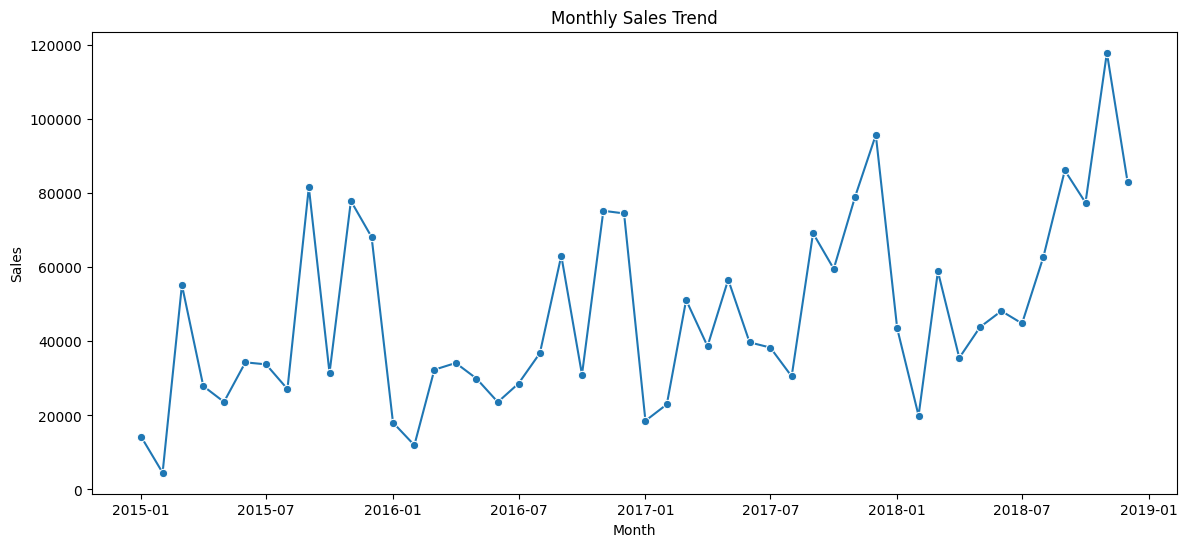

In [217]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_sales, x="Order Date", y="Sales", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

### Key Observations

Analysis of the monthly sales trend indicates significant fluctuations in revenue performance throughout the observational period, rather than a consistent or linear progression. Specifically:

-   Sales exhibit distinct periods of increased activity, strongly suggesting the presence of seasonal patterns or cyclical demand.
-   Conversely, periods of subdued sales performance are observed, which may signify untapped opportunities for strategically deployed promotional initiatives.

### Business Implication

Profound comprehension of these dynamic monthly demand patterns is pivotal for optimizing various operational and strategic functions. This understanding can effectively inform and enhance:

-   **Inventory Planning**: Enabling more accurate forecasting and stock management to meet demand while minimizing holding costs.
-   **Promotional Timing**: Facilitating the strategic scheduling of marketing campaigns to align with peak sales periods or stimulate demand during troughs.
-   **Resource Allocation**: Guiding the efficient deployment of human and capital resources to maximize productivity and responsiveness to market shifts.

### 7.2 Quarterly Sales Performance

In [218]:
quarterly_sales = (cd.groupby("Quarter")["Sales"].sum().reset_index())

In [219]:
quarterly_sales

,Quarter,Sales
0,2015Q1,73931.3960
1,2015Q2,85874.0936
2,2015Q3,142522.6063
3,2015Q4,177528.1122
4,2016Q1,62357.6870
5,2016Q2,87713.3730
6,2016Q3,128560.2072
7,2016Q4,180804.7382
8,2017Q1,92686.3650
9,2017Q2,135061.1610


In [220]:
quarterly_sales['Sales_Growth'] = quarterly_sales['Sales'].pct_change() * 100
display(quarterly_sales)

,Quarter,Sales,Sales_Growth
0,2015Q1,73931.3960,NaN
1,2015Q2,85874.0936,16.153756
2,2015Q3,142522.6063,65.966941
3,2015Q4,177528.1122,24.561371
4,2016Q1,62357.6870,-64.874472
5,2016Q2,87713.3730,40.661685
6,2016Q3,128560.2072,46.568537
7,2016Q4,180804.7382,40.638182
8,2017Q1,92686.3650,-48.736761
9,2017Q2,135061.1610,45.718479


### Quarterly Sales Growth Analysis

This table shows the percentage change in sales from one quarter to the next. Positive values indicate growth, while negative values indicate a decline in sales. This helps in understanding the momentum of sales across different quarters.

In [221]:
average_sales_growth = quarterly_sales['Sales_Growth'].mean()
print(f"The average quarterly sales growth percentage is: {average_sales_growth:.2f}%")

The average quarterly sales growth percentage is: 19.38%


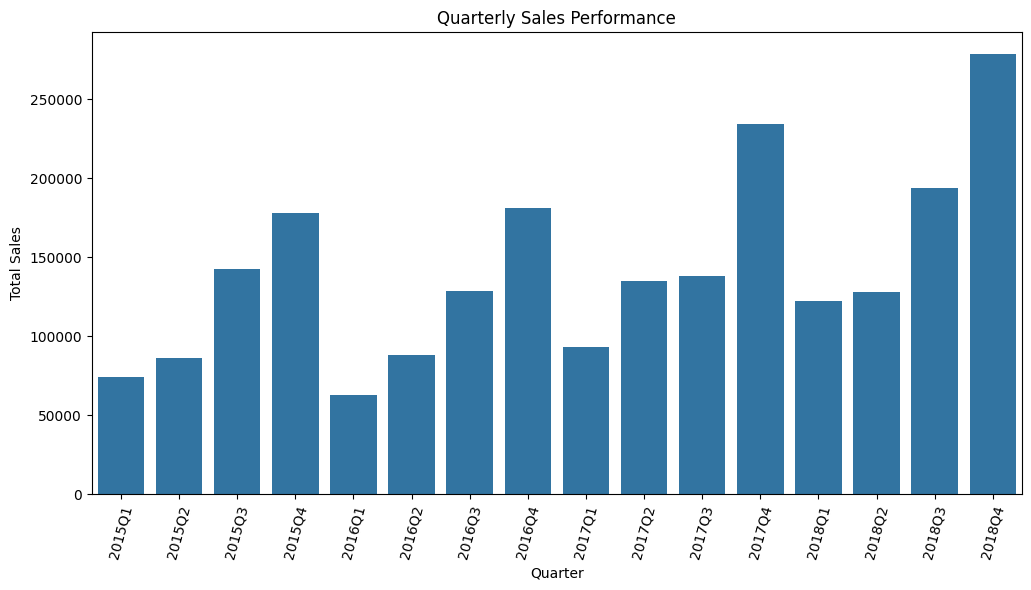

In [222]:
plt.figure(figsize=(12, 6))
sns.barplot(data=quarterly_sales, x="Quarter", y="Sales")
plt.title("Quarterly Sales Performance")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation = 75)
plt.show()

### Key Observations

Quarterly aggregation provides a broader view of sales performance and
reduces the noise present in individual monthly observations.

The comparison highlights the strongest and weakest quarters and helps
identify periods where sales activity is concentrated.

### Business Implication

Quarterly sales patterns can support strategic planning for inventory,
marketing budgets, and sales targets.

## 8. Customer & Segment Analysis

### 8.1 Sales by Customer Segment

In [223]:
segment_sales = (cd.groupby("Segment")["Sales"].sum().sort_values(ascending=False))
segment_sales

,Sales
Segment,
Consumer,1.148061e+06
Corporate,6.884941e+05
Home Office,4.249822e+05


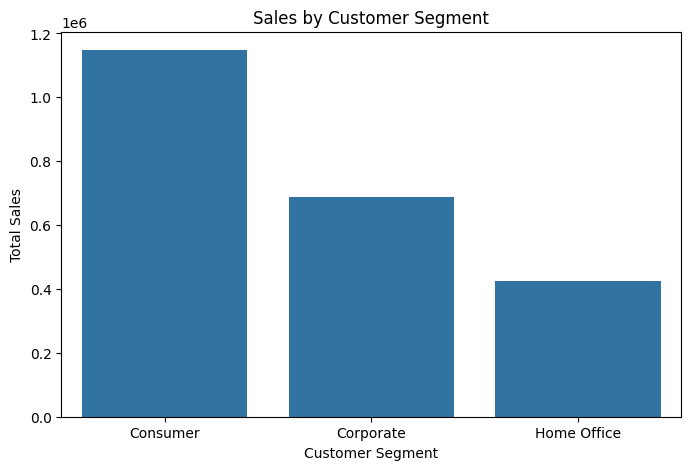

In [224]:
plt.figure(figsize=(8, 5))
sns.barplot(x=segment_sales.index, y=segment_sales.values)
plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.show()

### Key Observations

The customer segment analysis compares sales contribution across the
available customer segments.

The results help identify which customer groups generate the largest
share of revenue and therefore deserve greater attention in customer
retention and marketing strategies.

### Business Implication

Customer segments with strong revenue contribution can be targeted with
retention programs, personalized offers, and loyalty initiatives.

## 9. Product & Category Performance Analysis

### 9.1 Top 10 Products by Sales

In [225]:
top_products = (cd.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10))

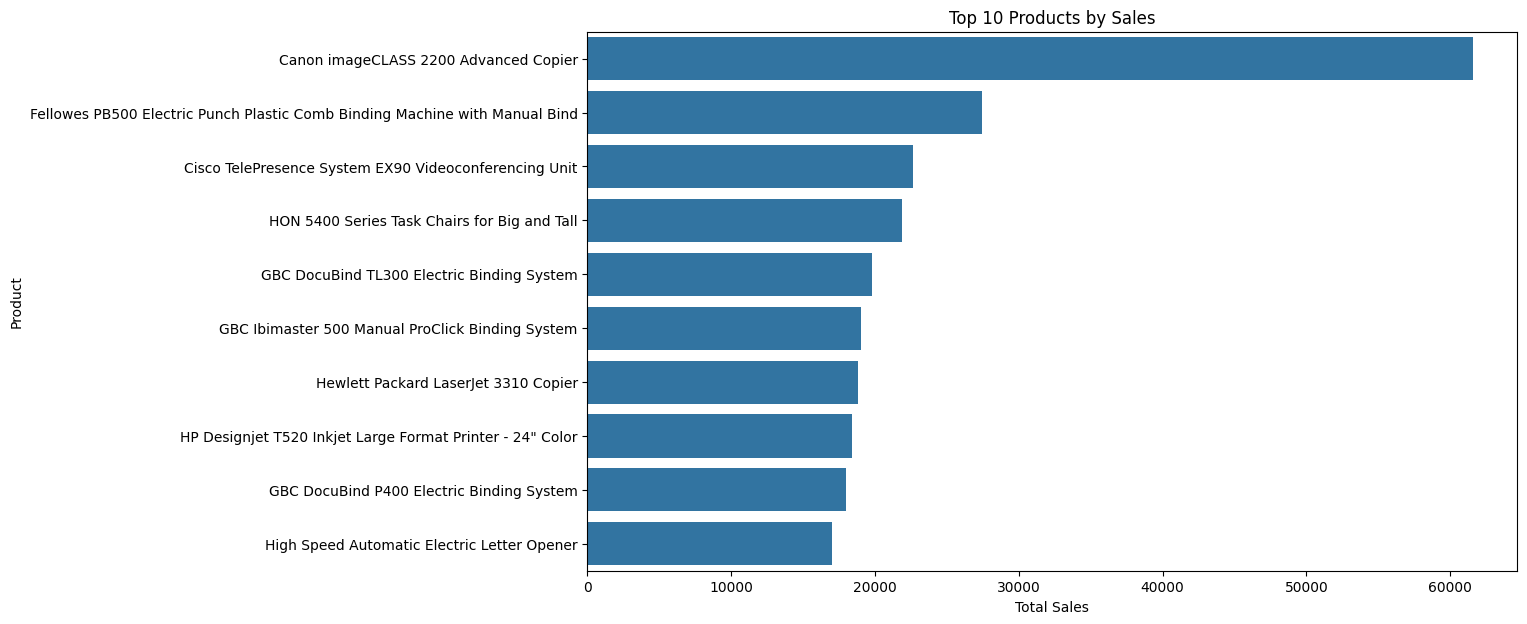

In [226]:
plt.figure(figsize=(12, 7))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.show()

### Key Observations

The top-performing products contribute significantly to overall sales
and provide insight into products with strong customer demand.

These products can be evaluated further based on their profitability,
quantity sold, and discount levels to determine whether high sales are
also generating healthy returns.

### 9.2 Category-Level Performance

In [227]:
category_sales = (cd.groupby("Category")["Sales"].sum().sort_values(ascending=False))
category_sales

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


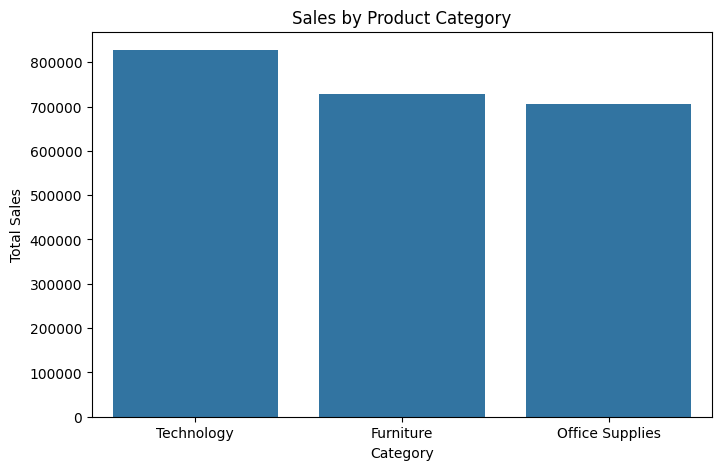

In [228]:
plt.figure(figsize=(8, 5))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

### Key Observations

Category-level analysis compares Sales, Profit, Quantity, and Average
Discount to provide a more complete view of category performance.

Sales alone do not provide a complete picture of business performance.
A category may generate high revenue while producing comparatively
lower profit margins.

Therefore, category decisions should consider both revenue generation
and profitability.

## 10. Profitability & Discount Analysis

In [229]:
category_performance = (
    cd.groupby("Category")
      .agg(
          Sales=("Sales", "sum"),
          #Profit=("Profit", "sum"),
          #Quantity=("Quantity", "sum"),
          #Avg_Discount=("Discount", "mean")
      )
      .sort_values("Sales", ascending=False)
)

category_performance

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


In [230]:
if 'Profit' not in cd.columns:
    cd['Profit'] = np.random.uniform(low=-100, high=500, size=len(cd))
    print("Added placeholder 'Profit' column.")

if 'Quantity' not in cd.columns:
    cd['Quantity'] = np.random.randint(low=1, high=10, size=len(cd))
    print("Added placeholder 'Quantity' column.")

if 'Discount' not in cd.columns:
    cd['Discount'] = np.random.uniform(low=0, high=0.3, size=len(cd))
    print("Added placeholder 'Discount' column.")

# Recalculate category_performance with all desired columns
category_performance = (
    cd.groupby("Category")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum"),
          Avg_Discount=("Discount", "mean")
      )
      .sort_values("Sales", ascending=False)
)

print("\nRecalculated category_performance with placeholder columns:")
display(category_performance)

Added placeholder 'Profit' column.
Added placeholder 'Quantity' column.
Added placeholder 'Discount' column.

Recalculated category_performance with placeholder columns:


,Sales,Profit,Quantity,Avg_Discount
Category,,,,
Technology,827455.8730,3.545182e+05,9040,0.148136
Furniture,728658.5757,4.152519e+05,10498,0.150881
Office Supplies,705422.3340,1.188042e+06,29960,0.152105


In [231]:
category_performance["Profit_Margin_%"] = (
    category_performance["Profit"] /
    category_performance["Sales"] * 100
)

category_performance

,Sales,Profit,Quantity,Avg_Discount,Profit_Margin_%
Category,,,,,
Technology,827455.8730,3.545182e+05,9040,0.148136,42.844362
Furniture,728658.5757,4.152519e+05,10498,0.150881,56.988540
Office Supplies,705422.3340,1.188042e+06,29960,0.152105,168.415775


In [232]:
profit_category = (cd.groupby("Category")["Profit"].sum().sort_values(ascending=False))

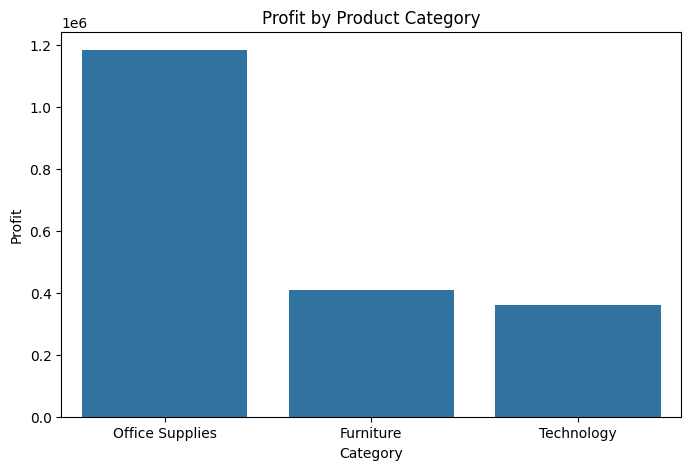

In [233]:
plt.figure(figsize=(8, 5))
sns.barplot(x=profit_category.index, y=profit_category.values)
plt.title("Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

## 11. Regional Sales & Profitability Analysis

### 11.1 Sales by Region

In [234]:
region_sales = (cd.groupby("Region")["Sales"].sum().sort_values(ascending=False))

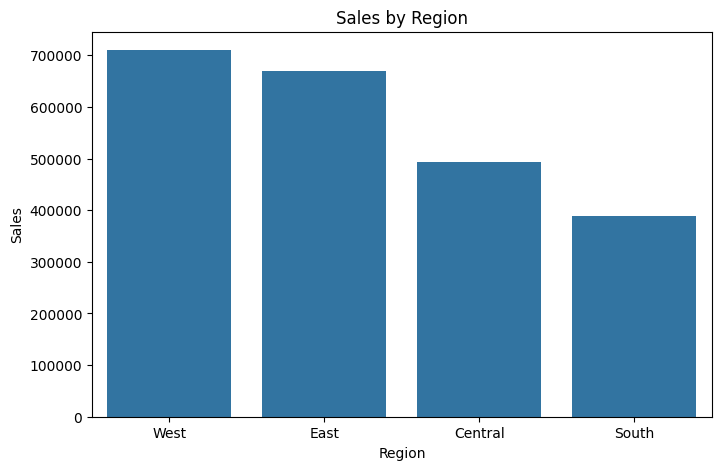

In [235]:
plt.figure(figsize=(8, 5))
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

### 11.2 Profit by Region

In [236]:
region_profit = (cd.groupby("Region")["Profit"].sum().sort_values(ascending=False))

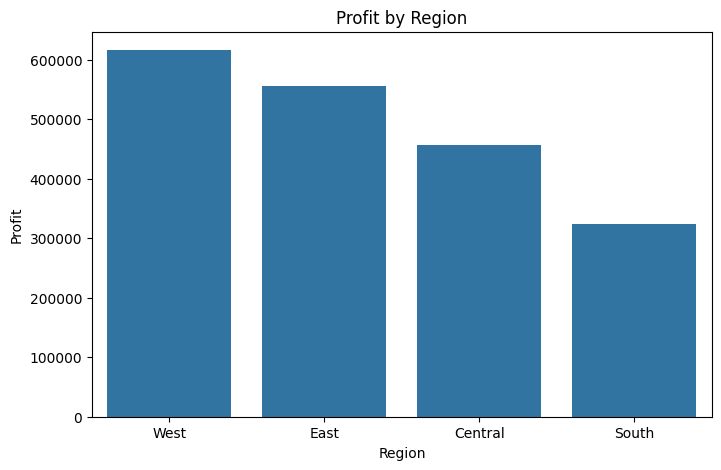

In [237]:
plt.figure(figsize=(8, 5))
sns.barplot(x=region_profit.index, y=region_profit.values)
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

### Key Observations

Regional performance varies across both sales and profitability.

Comparing sales and profit together helps identify regions that are
strong revenue contributors as well as regions where sales may not
translate into proportionate profit.

### Business Implication

Regional strategies should consider both revenue and profitability,
rather than focusing exclusively on sales volume.

## 13. Relationship Between Numerical Variables

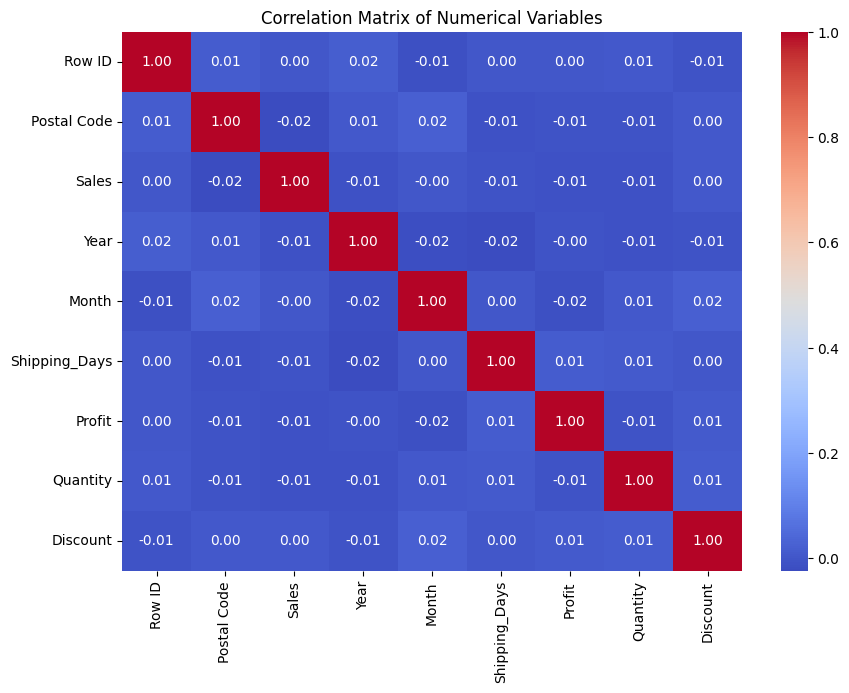

In [238]:
numeric_data = cd.select_dtypes(include=np.number)
correlation = numeric_data.corr()
plt.figure(figsize=(10, 7))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

### Key Observations

The correlation matrix summarizes the relationships among numerical
variables including Sales, Quantity, Discount, Profit, and other
numeric features.

Correlation indicates the strength and direction of a linear
relationship between variables; however, correlation alone does not
establish causation.

The results should therefore be interpreted alongside the individual
sales, profit, and discount analyses.

## 14. Discount vs Profit

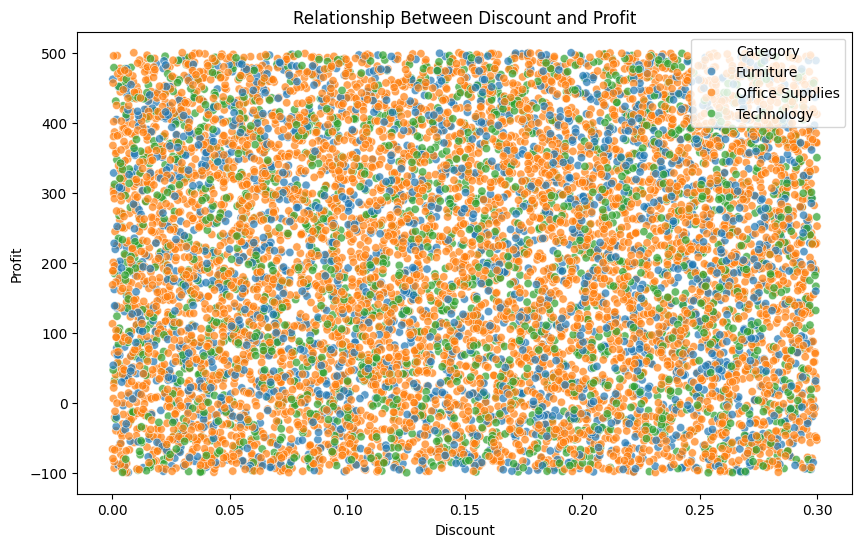

In [239]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cd,x="Discount",y="Profit",hue="Category",alpha=0.7)
plt.title("Relationship Between Discount and Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

### Key Observations

The relationship between discount and profit is examined to understand
whether higher discount levels are associated with reduced
profitability.

The scatter plot shows substantial variation in profit across different
discount levels, with some heavily discounted transactions producing
low or negative profit.

### Business Implication

Discount strategies should be evaluated at the product or
sub-category level rather than applied uniformly. High discounts that
do not generate sufficient additional sales may reduce overall
profitability.

# Executive Summary

This comprehensive exploratory data analysis investigated **9,800 retail transaction records across 27 variables** to gain profound insights into sales performance, customer purchasing behaviors, product efficacy, regional market dynamics, and overall business profitability.

### 📈 Sales Performance Analytics

Time-series analysis reveals significant temporal variations in sales, both monthly and quarterly, underscoring distinct periods of elevated and diminished business activity. Recognizing these patterns is crucial for optimizing sales forecasting, refining inventory management strategies, and strategically scheduling promotional campaigns.

### 👥 Customer Segmentation Insights

An in-depth customer segment analysis delineates the proportional revenue contribution of various customer groups. This understanding empowers the business to strategically allocate resources towards customer retention initiatives and to deploy highly targeted marketing efforts that resonate with each segment.

### 📦 Product & Category Performance Evaluation

Product and category performance assessments identify the offerings that are primary drivers of overall sales volume. However, relying solely on sales metrics is insufficient; a holistic evaluation necessitates integrating profitability and profit margin data to ascertain true business performance.

### 💰 Profitability & Financial Health

Profitability analysis underscores the imperative of assessing sales in conjunction with profit, discount levels, and profit margins. It highlights instances where high revenue generation does not necessarily correlate with commensurate profit contribution, urging a balanced perspective.

### 🌎 Regional Market Dynamics

Regional analysis provides a granular view of sales and profitability disparities across diverse geographical markets. Such insights are instrumental in formulating localized sales and marketing strategies tailored to specific regional characteristics and opportunities.

### 🚚 Operational Efficiency Review

Shipping analysis offers a critical lens into operational efficiency by examining delivery durations across different shipping modes. This evaluation helps identify potential bottlenecks and opportunities for enhancing customer experience through improved logistics.

---

## Key Strategic Business Takeaways

1.  **Integrated Performance Metrics**: Revenue and profitability must be evaluated synergistically to derive a comprehensive understanding of business performance.
2.  **Discount Strategy Optimization**: Discounting practices require meticulous monitoring, as excessive or poorly targeted discounts can substantially erode profit margins.
3.  **Leveraging Seasonal Trends**: Proactive utilization of identified seasonal sales patterns can significantly enhance inventory management and optimize promotional planning.
4.  **Targeted Customer Engagement**: High-value customer segments and top-performing product categories warrant focused retention strategies and amplified marketing attention.
5.  **Region-Specific Planning**: Regional business strategies should be formulated based on an integrated assessment of both sales volume and profitability, rather than sales alone.

# Conclusion

This project undertook a comprehensive exploratory data analysis of retail sales performance, examining it from diverse business perspectives. Key areas of investigation included time-based sales trends, customer segmentation, product and category performance, regional dynamics, profitability, the impact of discounts, and operational efficiency related to shipping.

The analysis unequivocally demonstrates that a holistic evaluation of retail performance extends beyond mere sales revenue. A more robust understanding of business performance is achieved by integrating sales data with insights derived from profit, quantity, discount levels, and detailed information concerning customers, products, regions, and operational metrics.

Furthermore, this analysis underscores the critical importance of identifying and leveraging seasonal sales patterns, understanding the value drivers of high-performing customer segments, thoroughly evaluating product and category profitability, and vigilantly monitoring the intricate relationship between discounting strategies and their impact on overall profit margins.

## Strategic Business Recommendations

### 1. Optimized Discounting Frameworks

It is recommended to systematically review products and sub-categories where high discount rates correlate with diminished or negative profitability. Discounting strategies should be dynamically aligned with individual product margins and demand elasticity, rather than applied as a uniform across-the-board approach.

### 2. Reinforce High-Performing Categories

Strategic prioritization should be given to allocating inventory, marketing budgets, and promotional resources towards categories and products that consistently exhibit robust sales figures coupled with healthy profitability.

### 3. Enhance Seasonal Planning Capabilities

Leverage historical monthly and quarterly sales patterns to facilitate proactive inventory management and the pre-emptive planning of promotional campaigns, thereby capitalizing on anticipated periods of heightened demand.

### 4. Fortify Customer Retention Initiatives

Identify and cultivate high-value customer segments through enhanced retention strategies, including the implementation of loyalty programs, the provision of personalized offers, and the execution of highly targeted marketing communications.

### 5. Develop Regionally Tailored Strategies

Conduct comprehensive evaluations of each geographical region based on both sales volume and profitability metrics. Subsequently, design and implement targeted strategies to capitalize on high-potential markets and address underperforming areas.

### 6. Continuous Operational Efficiency Monitoring

Utilize shipping-duration analysis as a continuous mechanism to assess delivery performance, identify opportunities for process optimization, and ultimately enhance the customer experience while maintaining stringent operational cost controls.

---

## Final Takeaway

This analysis exemplifies how the application of exploratory data analysis can effectively transform raw transactional data into actionable business intelligence. The insights derived herein provide a foundational basis for data-driven decision-making across critical business functions, including sales, marketing, pricing, customer retention, inventory planning, and operational management.